# Setup and Configs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from feature_visualization import FeatureAnalyzer
from dotenv import load_dotenv
from pathlib import Path

In [2]:
# -- Configs -- #
expansion_factor = 4
_lambda = 1e-2
gpt_dim = 768
feature_analysis_count = 25
sampling = True

project_root = Path().resolve().parent.parent
load_dotenv(project_root / ".env")

sampling_suffix = '_sampling' if sampling else ''
HF_dataset_path = f"thedarkknight7/SAE_monosemanticity_features_{expansion_factor}x_{_lambda}{sampling_suffix}"
table_name=f"hf_{expansion_factor}x_{str(_lambda).replace(".", "_")}_full{sampling_suffix}"

feature_analyzer = FeatureAnalyzer(
        HF_dataset_path = HF_dataset_path,
        db_name = str(project_root / "sae_feature_activations"),
        expansion_factor = expansion_factor
    )

feature_analyzer.create_features_table(table_name = table_name)
feature_analyzer.build_vocab_table()

/Users/aditya/Desktop/projects/sae-monosemantic/src/evaluation/feature_visualization.py:810: UserWarning: Table 'hf_4x_0_01_full_sampling' already exists. Skipping creation.
  warnings.warn(f"Table '{table_name}' already exists. Skipping creation.", UserWarning)


# Batch Feature Analysis

Filter features by selectivity (mean activation / log(num activations + 1)), take top/bottom k, then batch-analyze all of them. Results are cached so individual inspection is instant.

In [3]:
min_activations = 10

feature_selective_ranked = feature_analyzer.rank_features_by_selectivity(
    table_name=table_name,
    min_activations=min_activations
)
top_k_df = feature_selective_ranked.head(feature_analysis_count)
bottom_k_df = feature_selective_ranked.tail(feature_analysis_count)

In [4]:
def analyze_feature(feature_id: int) -> dict:
    top_act_df = feature_analyzer.get_top_activations(table_name, int(feature_id), top_k=25)
    top_act_df = feature_analyzer.reconstruct_token_text(top_act_df)
    top_act_df = feature_analyzer.reconstruct_context_text(top_act_df)

    labeled_df = feature_analyzer.label_feature(top_act_df, use_groq = False)
    llm_label = labeled_df["llm_label"].iloc[0]
    llm_reasoning = labeled_df["llm_reasoning"].iloc[0]

    stats = feature_analyzer.get_activation_distribution(table_name, int(feature_id))
    cooc = feature_analyzer.get_co_occuring_features(table_name, int(feature_id))
    breakdown = feature_analyzer.get_token_type_breakdown(int(feature_id), table_name)

    raw_activations = feature_analyzer.query(
        f"SELECT activation_value FROM {table_name} WHERE feature_id = {int(feature_id)}"
    )["activation_value"].values

    return {
        "feature_id": feature_id,
        "llm_label": llm_label,
        "llm_reasoning": llm_reasoning,
        "top_activations": labeled_df,
        "activation_stats": stats,
        "co_occurring_features": cooc,
        "token_type_breakdown": breakdown,
        "raw_activations": raw_activations,
    }

In [5]:
def display_feature_result(r: dict, show_histogram: bool = True):
    print("=" * 80)
    print(f"Feature {r['feature_id']}: {r['llm_label']}")
    if "group" in r:
        print(f"Group: {r['group']}")
    print("=" * 80)

    print(f"\n--- LLM Reasoning ---\n{r['llm_reasoning']}")

    print("\n--- Top Activations ---")
    display(r["top_activations"])

    print("\n--- Activation Distribution Stats ---")
    for k, v in r["activation_stats"].items():
        print(f"  {k}: {v}")

    if show_histogram and len(r["raw_activations"]) > 0:
        fig, ax = plt.subplots(figsize=(8, 3))
        ax.hist(r["raw_activations"], bins=50, color="steelblue", edgecolor="white", alpha=0.8)
        mean_val = r["activation_stats"]["mean_activation_score"]
        median_val = r["activation_stats"]["median_activation_score"]
        ax.axvline(mean_val, color="red", linestyle="--", linewidth=1.5, label=f"Mean: {mean_val:.3f}")
        ax.axvline(median_val, color="orange", linestyle="--", linewidth=1.5, label=f"Median: {median_val:.3f}")
        ax.set_title(f"Activation Distribution — Feature {r['feature_id']}")
        ax.set_xlabel("Activation Value")
        ax.set_ylabel("Count")
        ax.legend()
        plt.tight_layout()
        plt.show()

    print("\n--- Co-occurring Features ---")
    display(r["co_occurring_features"])

    print("\n--- Token Type Breakdown ---")
    for prop, counts in r["token_type_breakdown"].items():
        print(f"  {prop}: {counts}")

### Run Batch Analysis

In [6]:
batch_features = (
    [(fid, "top-k") for fid in top_k_df["feature_id"]]
    + [(fid, "bottom-k") for fid in bottom_k_df["feature_id"]]
)

batch_results = []
for fid, group in tqdm(batch_features, desc="Analyzing features"):
    r = analyze_feature(fid)
    r["group"] = group
    batch_results.append(r)

# Build summary DataFrame
batch_summary_df = pd.DataFrame([
    {
        "feature_id": r["feature_id"],
        "group": r["group"],
        "llm_label": r["llm_label"],
        "mean_activation": r["activation_stats"]["mean_activation_score"],
        "median_activation": r["activation_stats"]["median_activation_score"],
        "std_activation": r["activation_stats"]["standard_deviatin_activation_scores"],
        "unique_tokens": r["activation_stats"]["unique_token_id_count"],
    }
    for r in batch_results
])

print(f"\nBatch complete: {len(batch_results)} features analyzed.")
display(batch_summary_df)

Analyzing features:   0%|          | 0/50 [00:00<?, ?it/s]


Batch complete: 50 features analyzed.


,feature_id,group,llm_label,mean_activation,median_activation,std_activation,unique_tokens
0,1859,top-k,“Welcome” at start of text,60.059345,60.046608,0.246653,6
1,633,top-k,News article source/title headers,59.462376,59.462723,0.689356,199
2,1378,top-k,Sentence-initial indefinite pronouns/determiners,59.802822,59.701912,0.459002,332
3,948,top-k,Article or section starts,73.740219,73.694901,0.612772,1873
4,1197,top-k,News/article metadata labels,72.309563,72.280556,0.748690,1873
5,656,top-k,Headline-initial tokens,71.032875,71.103249,0.747867,1873
6,1374,top-k,Sentence-start capitalized fragments/new articles,71.000618,71.065269,0.747483,1873
7,2480,top-k,News article source/byline tokens,70.982735,70.986267,0.720312,1873
8,110,top-k,News article byline/source starts,70.912193,70.885460,0.673215,1873
9,1794,top-k,POLYSEMANTIC,70.283951,70.323471,0.560472,1873


### Individual Feature Inspector
Change `inspect_idx` and re-run to browse through batch results — no LLM calls needed.

[1/50]
Feature 1859: “Welcome” at start of text
Group: top-k

--- LLM Reasoning ---


--- Top Activations ---


,feature_id,activation_value,token_id,context_token_ids,chunk_id,token_text,context_text,context_string,llm_label,llm_reasoning
0,1859,60.046608,14618,"[262, 5175, 2196, 286, 262, 2524, 1844, 287, 3...",46,Welcome,"[ the, mobile, version, of, the, site, c...",the mobile version of the site complete in Oc...,“Welcome” at start of text,
1,1859,60.046608,14618,"[1043, 287, 4196, 338, 717, 7294, 1395, 36002,...",32,Welcome,"[ found, in, Apple, 's, first, OS, X, Ma...",found in Apple's first OS X Mavericks beta.**...,“Welcome” at start of text,
2,1859,60.046608,14618,"[340, 1107, 8338, 508, 262, 5871, 389, 13, 447...",23,Welcome,"[ it, really, depends, who, the, candidat...",it really depends who the candidates are.��**...,“Welcome” at start of text,
3,1859,60.046608,14618,"[13, 198, 198, 1135, 447, 247, 260, 1972, 612,...",17,Welcome,"[., \n, \n, We, �, �, re, getting, there, .,...",.\n\nWe��re getting there.**Welcome** to a cit...,“Welcome” at start of text,
4,1859,60.046608,14618,"[640, 284, 1282, 13, 198, 198, 7583, 319, 2272...",27,Welcome,"[ time, to, come, ., \n, \n, Also, on, For...",time to come.\n\nAlso on Forbes:**Welcome**!\...,“Welcome” at start of text,
5,1859,60.046608,14618,"[3802, 393, 302, 12, 9255, 262, 1578, 1829, 85...",8,Welcome,"[ enter, or, re, -, enter, the, United, S...",enter or re-enter the United States — illegal...,“Welcome” at start of text,
6,1859,60.046608,14618,"[345, 477, 262, 4998, 10969, 345, 5527, 306, 1...",45,Welcome,"[ you, all, the, amazing, presents, you, ...",you all the amazing presents you richly deser...,“Welcome” at start of text,
7,1859,60.046608,14618,"[4079, 3176, 2854, 13, 843, 262, 2854, 318, 23...",43,Welcome,"[ reflect, financial, performance, ., And, ...",reflect financial performance. And the perfor...,“Welcome” at start of text,
8,1859,60.046608,14618,"[329, 502, 284, 910, 428, 11, 475, 612, 389, 9...",16,Welcome,"[ for, me, to, say, this, ,, but, there,...","for me to say this, but there are good**Welco...",“Welcome” at start of text,
9,1859,60.046608,14618,"[481, 307, 12373, 306, 11829, 351, 13, 447, 25...",18,Welcome,"[ will, be, robust, ly, dealt, with, ., �,...",will be robustly dealt with.�� PA**Welcome** ...,“Welcome” at start of text,



--- Activation Distribution Stats ---
  mean_activation_score: 60.05934524536133
  median_activation_score: 60.046607971191406
  standard_deviatin_activation_scores: 0.24665291607379913
  activation_value_25th_percentile: 60.046607971191406
  activation_value_75th_percentile: 60.046607971191406
  unique_token_id_count: 6


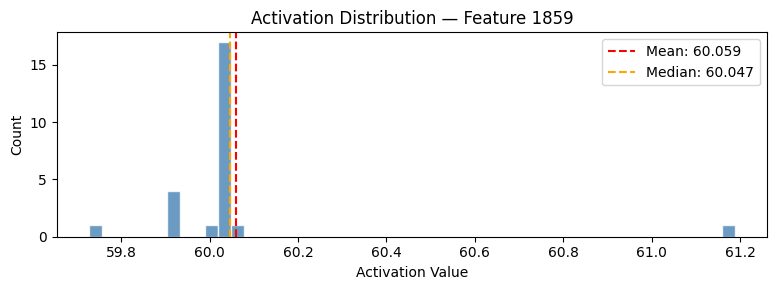


--- Co-occurring Features ---


,feature_id,co_occurrence_count,token_ids
0,2858,3,"[14618, 16773, 40028]"
1,2683,3,"[40028, 14618, 16773]"
2,2623,3,"[16773, 40028, 14618]"
3,2698,3,"[40028, 16773, 14618]"
4,1374,3,"[16773, 14618, 40028]"
...,...,...,...
168,2379,1,[14618]
169,1842,1,[14618]
170,2828,1,[14618]
171,1136,1,[40028]



--- Token Type Breakdown ---
  pos: {'NOUN': 10, 'PROPN': 5, 'ADJ': 5, 'X': 2, 'PUNCT': 1, 'ADP': 1, 'VERB': 1}
  ner: {'O': 21, 'ORG': 3, 'PERSON': 1}
  is_stop: {False: 25}
  is_punct: {False: 24, True: 1}
  dep: {'compound': 7, 'dobj': 4, 'punct': 3, '': 2, 'amod': 2, 'ROOT': 1, 'advmod': 1, 'prt': 1, 'pobj': 1, 'appos': 1, 'relcl': 1, 'nsubj': 1}
  subword_position: {'word_medial': 25}
  is_numeric: {False: 25}
  is_upper: {False: 25}
  is_title: {True: 25}
  is_whitespace: {False: 25}


In [7]:
inspect_idx = 0  # 0 to len(batch_results)-1

r = batch_results[inspect_idx]
print(f"[{inspect_idx + 1}/{len(batch_results)}]")
display_feature_result(r, show_histogram=True)

# Aggregate Analysis

### Monosemanticity Rate

In [8]:
polysemantic_count = sum(
    1 for r in batch_results if "POLYSEMANTIC" in r["llm_label"].upper()
)
total_count = len(batch_results)
monosemantic_rate = 1 - (polysemantic_count / total_count)

print(f"Monosemanticity Rate: {monosemantic_rate:.1%}")
print(f"  Polysemantic: {polysemantic_count}/{total_count}")
print(f"  Monosemantic: {total_count - polysemantic_count}/{total_count}")

for group in ["top-k", "bottom-k"]:
    group_results = [r for r in batch_results if r["group"] == group]
    group_poly = sum(1 for r in group_results if "POLYSEMANTIC" in r["llm_label"].upper())
    print(f"  {group}: {len(group_results) - group_poly}/{len(group_results)} monosemantic "
          f"({1 - group_poly / len(group_results):.1%})")

Monosemanticity Rate: 80.0%
  Polysemantic: 10/50
  Monosemantic: 40/50
  top-k: 21/25 monosemantic (84.0%)
  bottom-k: 19/25 monosemantic (76.0%)


### Feature Density

,feature_id,group,llm_label,mean_activation,median_activation,std_activation,unique_tokens,feature_density
0,1859,top-k,“Welcome” at start of text,60.059345,60.046608,0.246653,6,1.439427e-07
1,633,top-k,News article source/title headers,59.462376,59.462723,0.689356,199,4.301008e-06
2,1378,top-k,Sentence-initial indefinite pronouns/determiners,59.802822,59.701912,0.459002,332,1.000114e-05
3,948,top-k,Article or section starts,73.740219,73.694901,0.612772,1873,5.757709e-05
4,1197,top-k,News/article metadata labels,72.309563,72.280556,0.748690,1873,5.757709e-05
5,656,top-k,Headline-initial tokens,71.032875,71.103249,0.747867,1873,5.757709e-05
6,1374,top-k,Sentence-start capitalized fragments/new articles,71.000618,71.065269,0.747483,1873,5.757709e-05
7,2480,top-k,News article source/byline tokens,70.982735,70.986267,0.720312,1873,5.757709e-05
8,110,top-k,News article byline/source starts,70.912193,70.885460,0.673215,1873,5.757709e-05
9,1794,top-k,POLYSEMANTIC,70.283951,70.323471,0.560472,1873,5.757709e-05


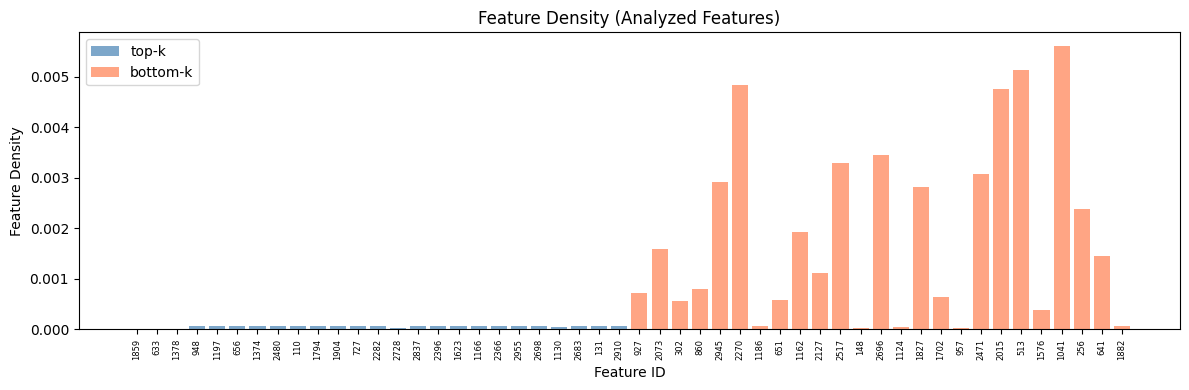

In [9]:
density_df = feature_analyzer.get_feature_density(table_name)

batch_summary_with_density = batch_summary_df.merge(density_df, on="feature_id", how="left")
display(batch_summary_with_density)

fig, ax = plt.subplots(figsize=(12, 4))
for group, color in [("top-k", "steelblue"), ("bottom-k", "coral")]:
    group_data = batch_summary_with_density[batch_summary_with_density["group"] == group]
    ax.bar(
        group_data["feature_id"].astype(str),
        group_data["feature_density"],
        color=color, alpha=0.7, label=group
    )
ax.set_xlabel("Feature ID")
ax.set_ylabel("Feature Density")
ax.set_title("Feature Density (Analyzed Features)")
ax.legend()
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.show()

### Pairwise Feature Similarity

Computing similarity matrix:   0%|          | 0/50 [00:00<?, ?it/s]

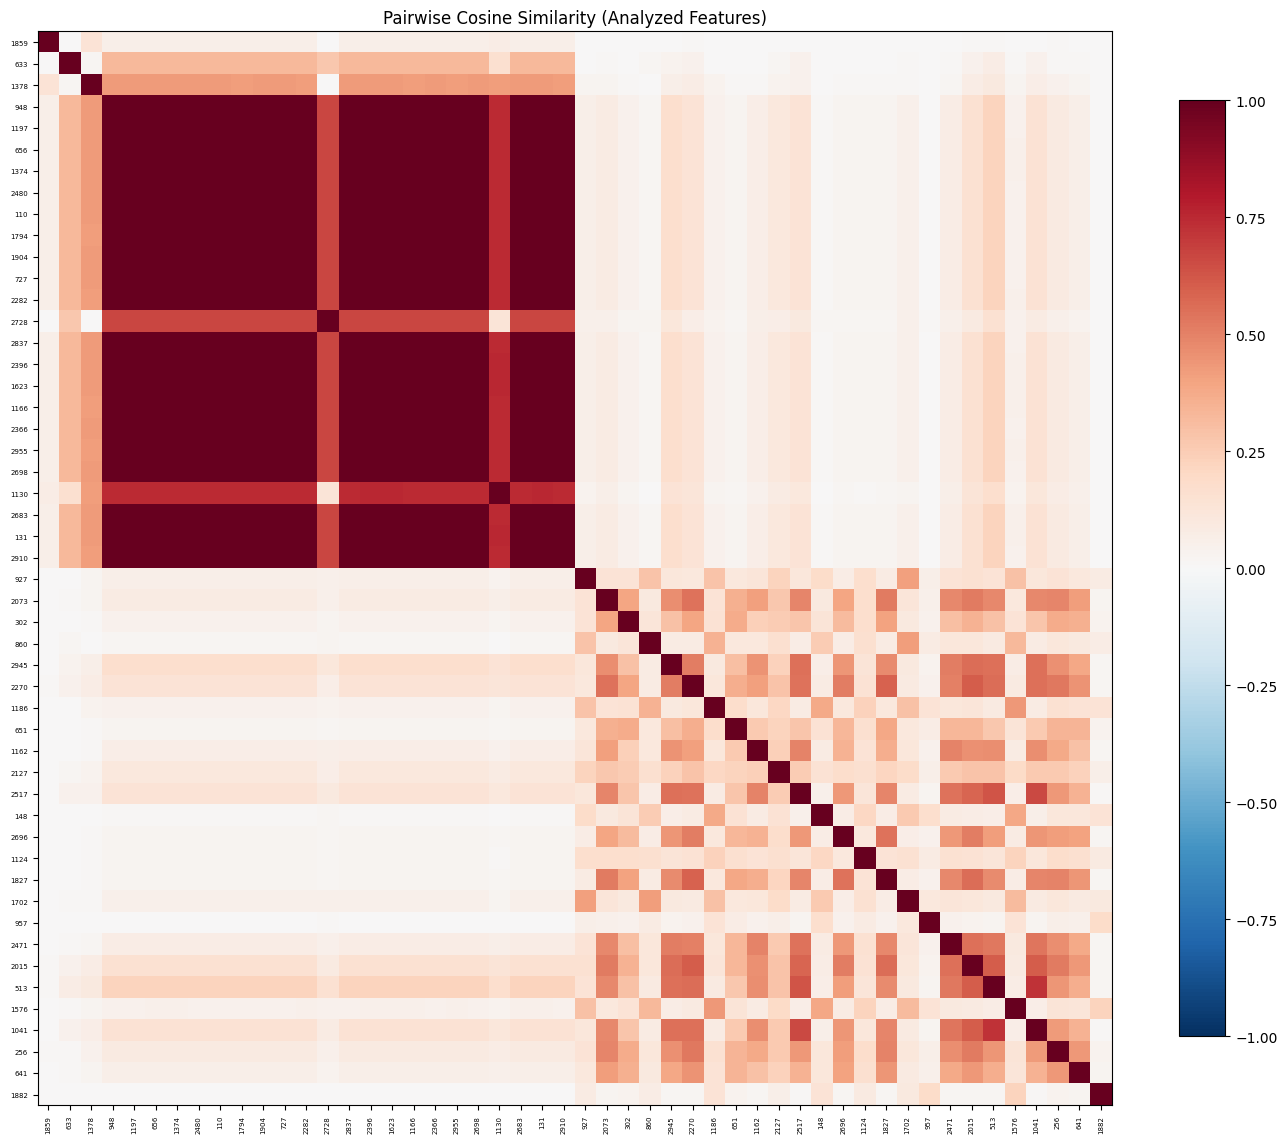

In [10]:
analyzed_feature_ids = [r["feature_id"] for r in batch_results]
n = len(analyzed_feature_ids)

sim_matrix = np.eye(n)
for i in tqdm(range(n), desc="Computing similarity matrix"):
    for j in range(i + 1, n):
        sim = feature_analyzer.feature_similarity_cosine_similarity(
            table_name, int(analyzed_feature_ids[i]), int(analyzed_feature_ids[j])
        )
        sim_matrix[i, j] = sim
        sim_matrix[j, i] = sim

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(sim_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
labels = [str(fid) for fid in analyzed_feature_ids]
ax.set_xticklabels(labels, rotation=90, fontsize=5)
ax.set_yticklabels(labels, fontsize=5)
ax.set_title("Pairwise Cosine Similarity (Analyzed Features)")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

### Activation Distribution Grid

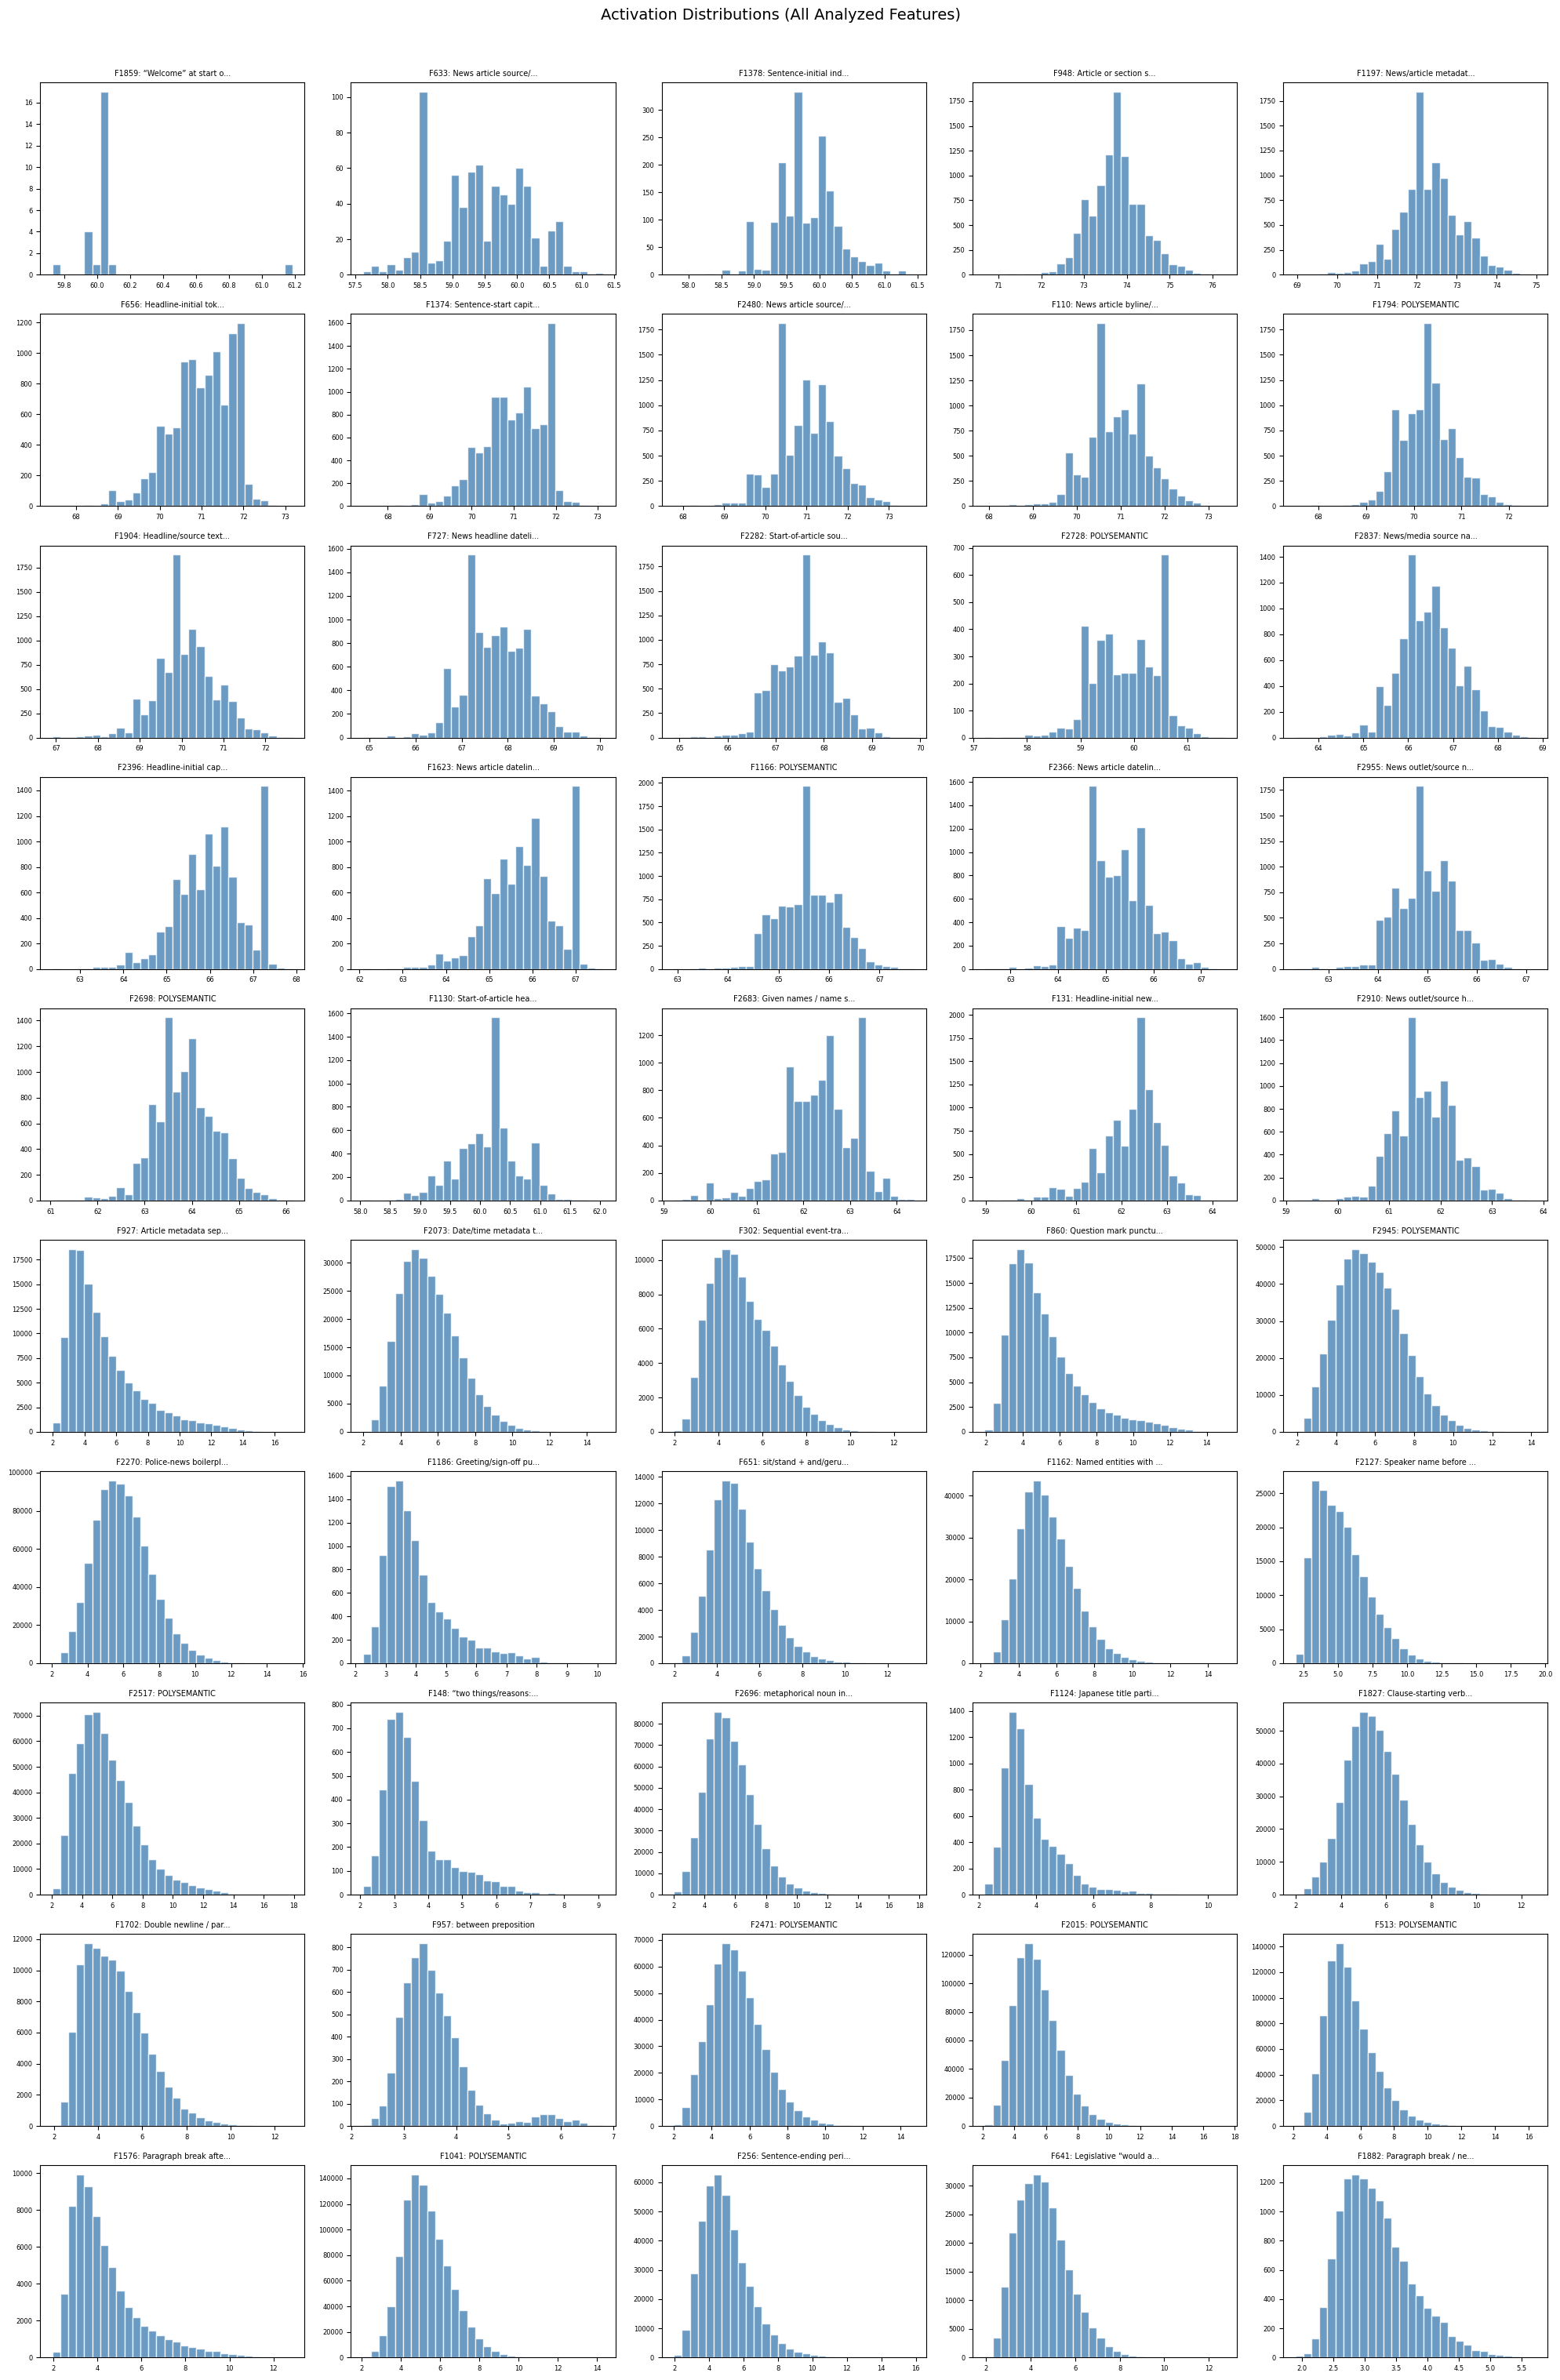

In [11]:
n_cols = 5
n_rows = (len(batch_results) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for idx, r in enumerate(batch_results):
    ax = axes[idx]
    ax.hist(r["raw_activations"], bins=30, color="steelblue", edgecolor="white", alpha=0.8)
    label_short = r["llm_label"][:20] + "..." if len(r["llm_label"]) > 20 else r["llm_label"]
    ax.set_title(f"F{r['feature_id']}: {label_short}", fontsize=7)
    ax.tick_params(labelsize=6)

for idx in range(len(batch_results), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Activation Distributions (All Analyzed Features)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Dead Feature Proportions

In [12]:
dead_df = feature_analyzer.get_dead_features()
dead_df

,feature_id
0,0
1,5
2,41
3,50
4,56
...,...
142,3012
143,3042
144,3051
145,3052


In [13]:
dead_proportion = len(dead_df)/(expansion_factor*gpt_dim)
dead_proportion

0.0478515625